In [1]:
!nvidia-smi

Fri Jun 26 14:16:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   35C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!git clone https://github.com/huongng389/Locality-iN-Locality.git

Cloning into 'Locality-iN-Locality'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 45 (delta 4), reused 2 (delta 2), pack-reused 40 (from 1)
Receiving objects: 100% (45/45), 45.99 KiB | 22.99 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [3]:
cd /content/Locality-iN-Locality

/content/Locality-iN-Locality


In [4]:
pip install torchattacks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 16.4 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
  Attempting uninstall: requests
    Found existing installation: re

In [5]:
import os
import sys
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.utils
from torchvision import models
import torchvision.datasets as dsets
import torchvision.transforms as transforms

import torchattacks
from torchattacks import PGD, FGSM
from torchsummary import summary

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.benchmark = True


In [6]:
print("PyTorch", torch.__version__)
print("Torchvision", torchvision.__version__)
print("Torchattacks", torchattacks.__version__)
print("Numpy", np.__version__)

PyTorch 2.11.0+cu128
Torchvision 0.26.0+cu128
Torchattacks 3.5.1
Numpy 2.0.2


## GTSRB

In [7]:
!mkdir data

!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip -o data/GTSRB_Final_Training_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip -o data/GTSRB_Final_Test_Images.zip
!curl --url https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip -o data/GTSRB_Final_Test_GT.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  263M  100  263M    0     0  11.7M      0  0:00:22  0:00:22 --:--:-- 14.3M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.8M  100 84.8M    0     0  6304k      0  0:00:13  0:00:13 --:--:-- 6795k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 99620  100 99620    0     0  68331      0  0:00:01  0:00:01 --:--:-- 68373


In [8]:
!unzip data/GTSRB_Final_Training_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_Images.zip -d data/ > /dev/null 2>&1
!unzip data/GTSRB_Final_Test_GT.zip -d data/

Archive:  data/GTSRB_Final_Test_GT.zip
  inflating: data/GT-final_test.csv  


In [9]:
import shutil

In [10]:
data_dir = './data/GTSRB'
images_dir = os.path.join(data_dir, 'Final_Test/Images')

test_dir = os.path.join(data_dir, 'test')
os.makedirs(test_dir, exist_ok=True)



with open('./data/GT-final_test.csv') as f:
  image_names = f.readlines()

for text in image_names[1:]:
  classes = int(text.split(';')[-1])
  image_name = text.split(';')[0]


  test_class_dir = os.path.join(test_dir, f"{classes:04d}")
  os.makedirs(test_class_dir, exist_ok=True)
  image_path = os.path.join(images_dir, image_name)

  shutil.copy(image_path, test_class_dir)

In [11]:
#Affine = transforms.RandomApply([transforms.RandomAffine(degrees=(0, 30),shear=(0.1, 0.2))], p=0.7)
#GaussianBlur = transforms.RandomApply([transforms.GaussianBlur((3,7) , sigma=(5))], p=0.7)
#Perspective = transforms.RandomPerspective(0.5, p = 0.7)
#HSV1 = transforms.RandomApply([transforms.ColorJitter(brightness=0.3, contrast=.2)], p=0.7)
#HSV2 = transforms.RandomApply([transforms.ColorJitter(saturation= .2, hue=0.2)], p=0.7)
#miror = transforms.RandomHorizontalFlip(p=0.7)
#Randomcrop = transforms.RandomApply([transforms.RandomResizedCrop(100)], p=0.7)

#transform_list = [GaussianBlur, Affine, Perspective, HSV1, HSV2, Randomcrop]


In [12]:
batch_size = 64
num_workers = 2

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.82, 1.0), ratio=(0.90, 1.10)),
    transforms.RandomApply([
        transforms.RandomAffine(degrees=12, translate=(0.06, 0.06), scale=(0.90, 1.10), shear=5)
    ], p=0.75),
    transforms.RandomApply([transforms.RandomPerspective(distortion_scale=0.12)], p=0.20),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.24, contrast=0.24, saturation=0.20, hue=0.025)
    ], p=0.58),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.08),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.RandomErasing(p=0.08, scale=(0.01, 0.04), ratio=(0.3, 3.3), value='random'),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

raw_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

trainset = torchvision.datasets.ImageFolder(
    root='./data/GTSRB/Final_Training/Images',
    transform=train_transform,
)

testset = torchvision.datasets.ImageFolder(
    root='./data/GTSRB/test',
    transform=test_transform,
)

raw_testset = torchvision.datasets.ImageFolder(
    root='./data/GTSRB/test',
    transform=raw_test_transform,
)

train_loader = torch.utils.data.DataLoader(
    dataset=trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=num_workers > 0,
)

test_loader = torch.utils.data.DataLoader(
    dataset=testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=num_workers > 0,
)

raw_test_loader = torch.utils.data.DataLoader(
    dataset=raw_testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=num_workers > 0,
)


In [13]:
batch = next(iter(train_loader))
train_data = batch[0]

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_image(image):
    image_min = image.min()
    image_max = image.max()
    image.clamp_(min = image_min, max = image_max)
    image.add_(-image_min).div_(image_max - image_min + 1e-5)
    return image

def plot_images(images, labels, classes, normalize=True):

    n_images = len(images)

    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(20, 20))

    for i in range(rows*cols):

        ax = fig.add_subplot(rows, cols, i+1)

        image = images[i]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.permute(1, 2, 0).cpu().numpy())
        ax.set_title(classes[labels[i]])
        ax.axis('off')

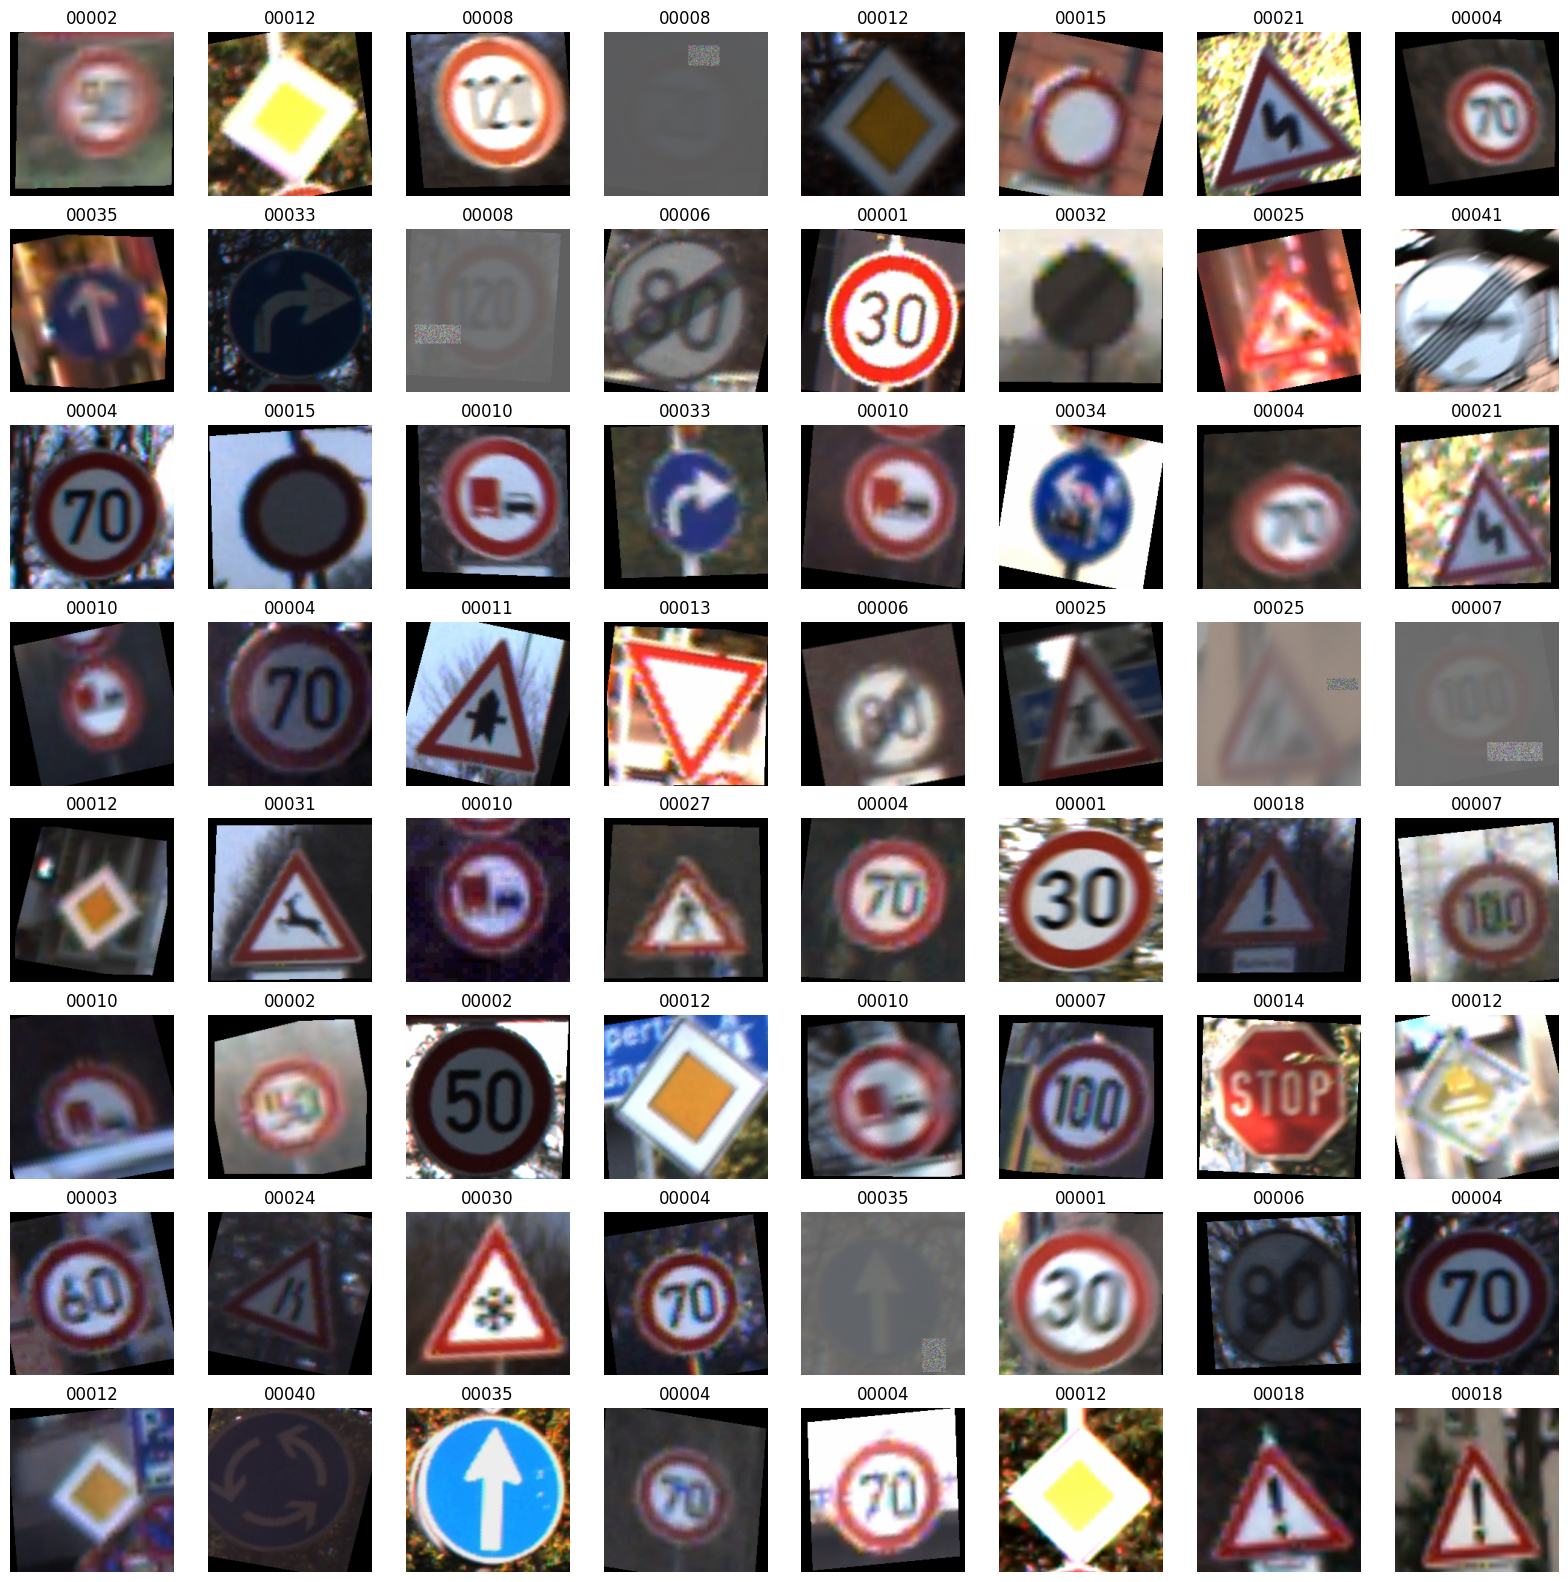

In [15]:
classes = trainset.classes

plot_images(batch[0], batch[1], classes)

## model

In [16]:
pip install timm

In [17]:
pip install einops

In [18]:
from LNL_Ti_996 import LNL_Ti_996 as small


/usr/local/lib/python3.12/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/content/Locality-iN-Locality/models/deit.py:78: UserWarning: Overwriting deit_tiny_patch16_224 in registry with models.deit.deit_tiny_patch16_224. This is because the name being registered

In [19]:
model = small(pretrained=False)


In [20]:
model.head

Linear(in_features=192, out_features=1000, bias=True)

In [21]:
model.head = torch.nn.Linear(in_features=192, out_features=43, bias=True)

In [22]:
model = model.cuda()

## Pretrained

In [ ]:
model.load_state_dict(torch.load("LNL_Ti_996_GTSRB.pth", map_location="cuda"))
model.eval()

## Train Locality-iN-Locality

In [23]:
num_epochs = 35
best_path = 'LNL_Ti_996_GTSRB_best.pth'
final_path = 'LNL_Ti_996_GTSRB.pth'


In [24]:
loss = nn.CrossEntropyLoss(label_smoothing=0.02)

def param_groups_weight_decay(model, weight_decay):
    decay = []
    no_decay = []
    skip = set(model.no_weight_decay()) if hasattr(model, 'no_weight_decay') else set()
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if param.ndim <= 1 or name.endswith('.bias') or name in skip:
            no_decay.append(param)
        else:
            decay.append(param)
    return [
        {'params': no_decay, 'weight_decay': 0.0},
        {'params': decay, 'weight_decay': weight_decay},
    ]

optimizer = torch.optim.AdamW(param_groups_weight_decay(model, 0.04), lr=4e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=8e-6)
scaler = torch.amp.GradScaler('cuda')
best_train_loss = float('inf')


In [25]:
for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0
    total_batch = len(train_loader)

    for i, (batch_images, batch_labels) in enumerate(train_loader):
        X = batch_images.cuda(non_blocking=True)
        Y = batch_labels.cuda(non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            pre = model(X)
            cost = loss(pre, Y)

        scaler.scale(cost).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += cost.item()
        if (i + 1) % 200 == 0:
            print('Epoch [%d/%d], Iter [%d/%d], Avg Loss: %.6f'
                 % (epoch + 1, num_epochs, i + 1, total_batch, running_loss / (i + 1)))

    scheduler.step()
    epoch_loss = running_loss / total_batch
    if epoch_loss < best_train_loss:
        best_train_loss = epoch_loss
        torch.save(model.state_dict(), best_path)
        print('Saved best model by train loss: %.6f -> %s' % (best_train_loss, best_path))

model.load_state_dict(torch.load(best_path, map_location='cuda'))
torch.save(model.state_dict(), final_path)
print('Model saved as %s' % final_path)


Epoch [1/35], Iter [200/613], Avg Loss: 2.478253
Epoch [1/35], Iter [400/613], Avg Loss: 1.510197
Epoch [1/35], Iter [600/613], Avg Loss: 1.091193
Saved best model by train loss: 1.073382 -> LNL_Ti_996_GTSRB_best.pth
Epoch [2/35], Iter [200/613], Avg Loss: 0.222869
Epoch [2/35], Iter [400/613], Avg Loss: 0.219101
Epoch [2/35], Iter [600/613], Avg Loss: 0.214744
Saved best model by train loss: 0.214596 -> LNL_Ti_996_GTSRB_best.pth
Epoch [3/35], Iter [200/613], Avg Loss: 0.197078
Epoch [3/35], Iter [400/613], Avg Loss: 0.194900
Epoch [3/35], Iter [600/613], Avg Loss: 0.196160
Saved best model by train loss: 0.195927 -> LNL_Ti_996_GTSRB_best.pth
Epoch [4/35], Iter [200/613], Avg Loss: 0.195559
Epoch [4/35], Iter [400/613], Avg Loss: 0.193997
Epoch [4/35], Iter [600/613], Avg Loss: 0.193223
Saved best model by train loss: 0.193384 -> LNL_Ti_996_GTSRB_best.pth
Epoch [5/35], Iter [200/613], Avg Loss: 0.189328
Epoch [5/35], Iter [400/613], Avg Loss: 0.190880
Epoch [5/35], Iter [600/613], Avg 

## Test

In [26]:
model.eval()
top1_correct = 0
top5_correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.cuda(non_blocking=True)
        labels = labels.cuda(non_blocking=True)
        with torch.amp.autocast('cuda'):
            outputs = model(images)

        total += labels.size(0)
        top1_correct += (outputs.argmax(dim=1) == labels).sum().item()
        top5_correct += outputs.topk(5, dim=1).indices.eq(labels.view(-1, 1)).any(dim=1).sum().item()

print('Top-1 accuracy: %.2f %%' % (100 * top1_correct / total))
print('Top-5 accuracy: %.2f %%' % (100 * top5_correct / total))


Top-1 accuracy: 99.69 %
Top-5 accuracy: 99.98 %


## Download

In [27]:
from google.colab import files

files.download(final_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## FGSM attack

In [28]:
class NormalizeWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.register_buffer('mean', torch.tensor((0.5, 0.5, 0.5)).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor((0.5, 0.5, 0.5)).view(1, 3, 1, 1))

    def forward(self, x):
        x = (x - self.mean) / self.std
        return self.model(x)

model.eval()
attack_model = NormalizeWrapper(model).cuda().eval()
correct = 0
total = 0

atk = FGSM(attack_model, eps=0.01)

for images, labels in raw_test_loader:
    images = images.cuda(non_blocking=True)
    labels = labels.cuda(non_blocking=True)
    adv_images = atk(images, labels)

    with torch.no_grad(), torch.amp.autocast('cuda'):
        outputs = attack_model(adv_images)

    predicted = outputs.argmax(dim=1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print('FGSM robust Top-1 accuracy: %.2f %%' % (100 * correct / total))


FGSM robust Top-1 accuracy: 92.79 %


## PGD attack

In [29]:
model.eval()
attack_model = NormalizeWrapper(model).cuda().eval()
correct = 0
total = 0

atk = PGD(attack_model, eps=0.01, alpha=2/255, steps=5, random_start=False)

for images, labels in raw_test_loader:
    images = images.cuda(non_blocking=True)
    labels = labels.cuda(non_blocking=True)
    adv_images = atk(images, labels)

    with torch.no_grad(), torch.amp.autocast('cuda'):
        outputs = attack_model(adv_images)

    predicted = outputs.argmax(dim=1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print('PGD robust Top-1 accuracy: %.2f %%' % (100 * correct / total))


PGD robust Top-1 accuracy: 63.49 %


## train LNL-MoEx

In [30]:
# Optional original LNL-MoEx section is skipped in this LNL_Ti_996 run.


In [31]:
# Optional original LNL-MoEx section is skipped in this LNL_Ti_996 run.


In [32]:
# Optional original LNL-MoEx section is skipped in this LNL_Ti_996 run.


In [33]:
# Optional original LNL-MoEx section is skipped in this LNL_Ti_996 run.


In [34]:
# Optional original LNL-MoEx section is skipped in this LNL_Ti_996 run.


In [35]:
# Optional original LNL-MoEx section is skipped in this LNL_Ti_996 run.


## Number of Parameters

In [36]:
pip install ptflops

In [37]:
pip install --upgrade git+https://github.com/sovrasov/flops-counter.pytorch.git

  Cloning https://github.com/sovrasov/flops-counter.pytorch.git to /tmp/pip-req-build-xgdwv0ih
  Running command git clone --filter=blob:none --quiet https://github.com/sovrasov/flops-counter.pytorch.git /tmp/pip-req-build-xgdwv0ih
  Resolved https://github.com/sovrasov/flops-counter.pytorch.git to commit d612c7547445841a325fd2a1ff2ab27583f01bae
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ptflops: filename=ptflops-0.7.6-py3-none-any.whl size=19501 sha256=aebafd937d59e4d755c16dcc6a98f8dedcfda7dabb6562a381fdef3ea062f541
  Stored in directory: /tmp/pip-ephem-wheel-cache-yrnexjqy/wheels/c3/60/94/c0a4677f6c1ff199ef7a6717fa47797ea51309624895931fe9
Successfully built ptflops
  Attempting uninstall: ptflops
    Found existing installation: ptflops 0.7.5
    Uninstalling ptflops-0.7.5:
      Successfully uninstalled ptflops-0.7.5


In [38]:
import torch
from ptflops import get_model_complexity_info

with torch.cuda.device(0):
  net = model
  macs, params = get_model_complexity_info(net, (3, 224, 224), as_strings=True,
                                           print_per_layer_stat=True, verbose=True)
  print('{:<30}  {:<8}'.format('Computational complexity: ', macs))
  print('{:<30}  {:<8}'.format('Number of parameters: ', params))


LNLTi996(
  6.15 M, 99.383% Params, 1.24 GMac, 99.710% MACs, 
  (pixel_embed): PixelEmbed(
    1.78 k, 0.029% Params, 5.57 MMac, 0.446% MACs, 
    (proj): Conv2d(1.78 k, 0.029% Params, 5.57 MMac, 0.446% MACs, 3, 12, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
    (unfold): Unfold(0, 0.000% Params, 0.0 Mac, 0.000% MACs, kernel_size=4, dilation=1, padding=0, stride=4)
  )
  (norm1_proj): LayerNorm(384, 0.006% Params, 37.63 KMac, 0.003% MACs, (192,), eps=1e-05, elementwise_affine=True)
  (proj): Linear(37.06 k, 0.599% Params, 7.26 MMac, 0.582% MACs, in_features=192, out_features=192, bias=True)
  (norm2_proj): LayerNorm(384, 0.006% Params, 37.63 KMac, 0.003% MACs, (192,), eps=1e-05, elementwise_affine=True)
  (pos_drop): Dropout(0, 0.000% Params, 0.0 Mac, 0.000% MACs, p=0.05, inplace=False)
  (blocks): ModuleList(
    (0): Block(
      499.16 k, 8.066% Params, 102.59 MMac, 8.222% MACs, 
      (norm_in): LayerNorm(24, 0.000% Params, 37.63 KMac, 0.003% MACs, (12,), eps=1e-05, element